# EMG Recording Analysis
**Channels:** CH1=RF, CH2=BF, CH3=GAS, CH4=TA
**Protocol:** Stand still → MVC → Stomp → Walk (ramp up) → Stand still  
**Fs:** 500 Hz

In [1]:
import struct
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import signal

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Load Binary Data

In [2]:
# ── CONFIG ──────────────────────────────────────────────
BIN_FILE   = '260417_01.bin'   # change path if needed
FS         = 500             # Hz
HEADER_VAL = 0xDEADBEEF
FOOTER_VAL = 0xBEEFDEAD
CH_NAMES   = ['CH1 (RF)', 'CH2 (BF)', 'CH3 (GAS)', 'CH4 (TA)']
CH_COLORS  = ['C0', 'C1', 'C2', 'C3']

# struct: uint32 timestamp | uint16[4] adc | int16[10] imu | float[3] leftMotor | float[3] rightMotor | int8 mode
FMT        = '<I4H10h6fb'
RECORD_SIZE = struct.calcsize(FMT)
print(f"Record size: {RECORD_SIZE} bytes")

# ── PARSE ───────────────────────────────────────────────
with open(BIN_FILE, 'rb') as f:
    raw = f.read()

header_bytes = struct.pack('<I', HEADER_VAL)
footer_bytes = struct.pack('<I', FOOTER_VAL)
h = raw.find(header_bytes)
foot = raw.rfind(footer_bytes)
payload = raw[h+4:foot]

n = len(payload) // RECORD_SIZE
records = [struct.unpack_from(FMT, payload, i*RECORD_SIZE) for i in range(n)]

timestamps = np.array([r[0] for r in records], dtype=np.float64)
t          = (timestamps - timestamps[0]) / 1000.0   # seconds
adc        = np.array([[r[1],r[2],r[3],r[4]] for r in records], dtype=np.float32)
imu        = np.array([[r[5+i] for i in range(10)] for r in records], dtype=np.float32)
mode       = np.array([r[-1] for r in records], dtype=np.int8)

print(f"Records: {n}  |  Duration: {t[-1]:.1f} s  |  Fs: {FS} Hz")
print(f"\nADC stats (raw 0-4095):")
for i, name in enumerate(CH_NAMES):
    sat_pct = (adc[:,i] >= 4090).mean() * 100
    print(f"  {name}: mean={adc[:,i].mean():.0f}  std={adc[:,i].std():.0f}  sat={sat_pct:.1f}%")

Record size: 57 bytes
Records: 14129  |  Duration: 111.0 s  |  Fs: 500 Hz

ADC stats (raw 0-4095):
  CH1 (RF): mean=3293  std=217  sat=1.3%
  CH2 (BF): mean=3273  std=115  sat=0.2%
  CH3 (GAS): mean=3259  std=159  sat=0.4%
  CH4 (TA): mean=3252  std=247  sat=1.5%


## 2. Overview Plot — Raw ADC + IMU
Use this to identify the MVC and stomp windows visually.

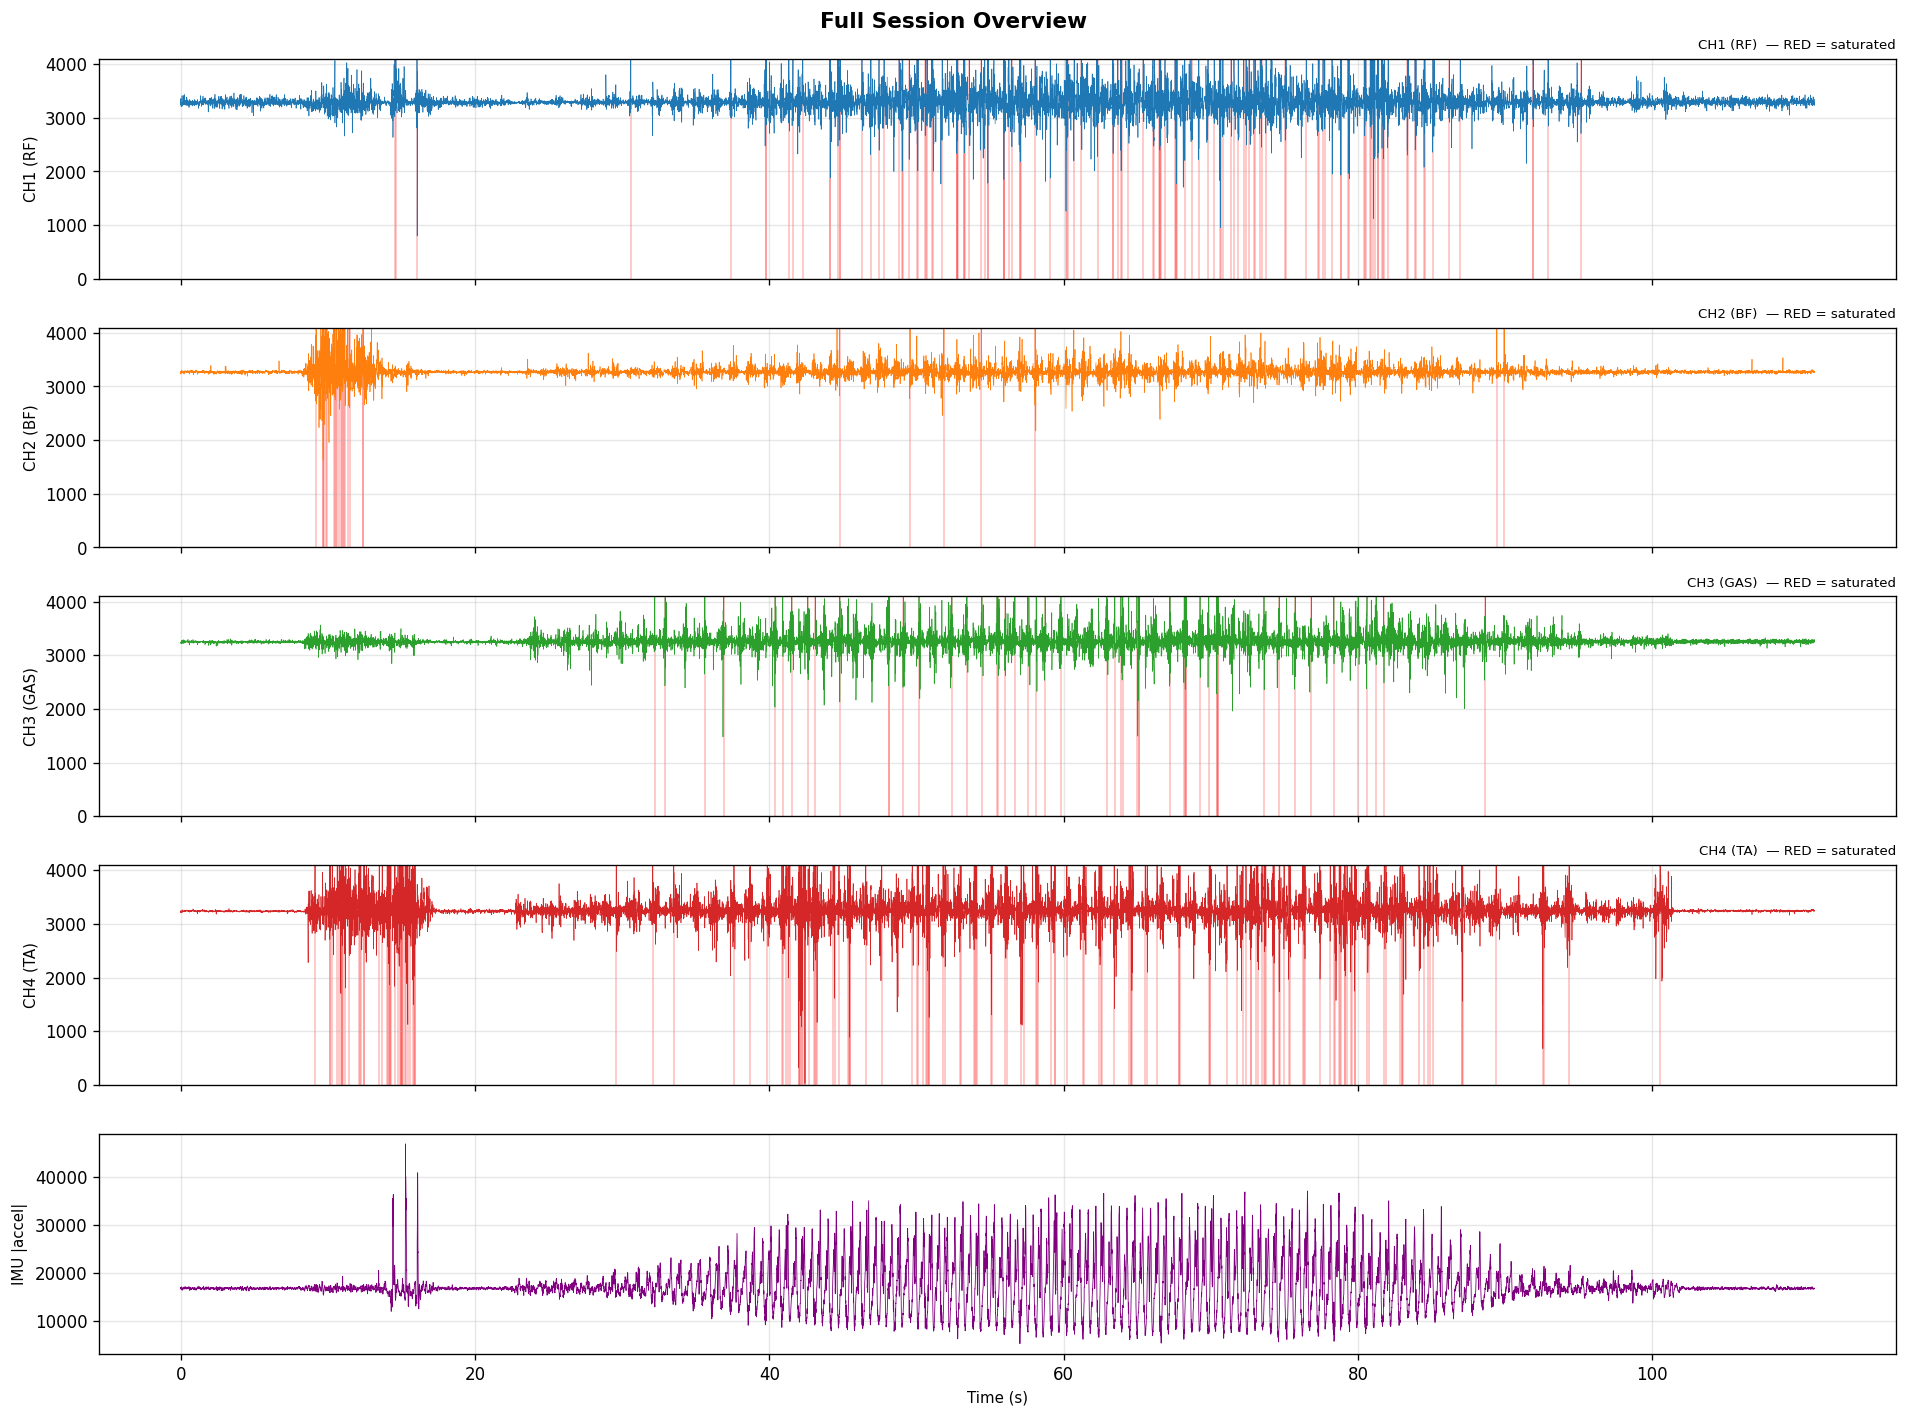

In [3]:
fig, axes = plt.subplots(5, 1, figsize=(16, 12), sharex=True)
fig.suptitle('Full Session Overview', fontsize=13, fontweight='bold')

for i in range(4):
    axes[i].plot(t, adc[:,i], lw=0.4, color=CH_COLORS[i])
    axes[i].set_ylabel(CH_NAMES[i], fontsize=9)
    axes[i].set_ylim(0, 4095)
    sat = adc[:,i] >= 4090
    if sat.any():
        axes[i].fill_between(t, 0, 4095, where=sat, alpha=0.25, color='red')
        axes[i].set_title(f'{CH_NAMES[i]}  — RED = saturated', fontsize=8, loc='right')

# IMU magnitude as activity proxy
accel_mag = np.sqrt((imu[:,:3]**2).sum(axis=1))
axes[4].plot(t, accel_mag, lw=0.5, color='purple')
axes[4].set_ylabel('IMU |accel|', fontsize=9)
axes[4].set_xlabel('Time (s)', fontsize=9)

plt.tight_layout()
plt.show()

## 3. Mark Epochs
Edit the times below after inspecting the overview plot above.

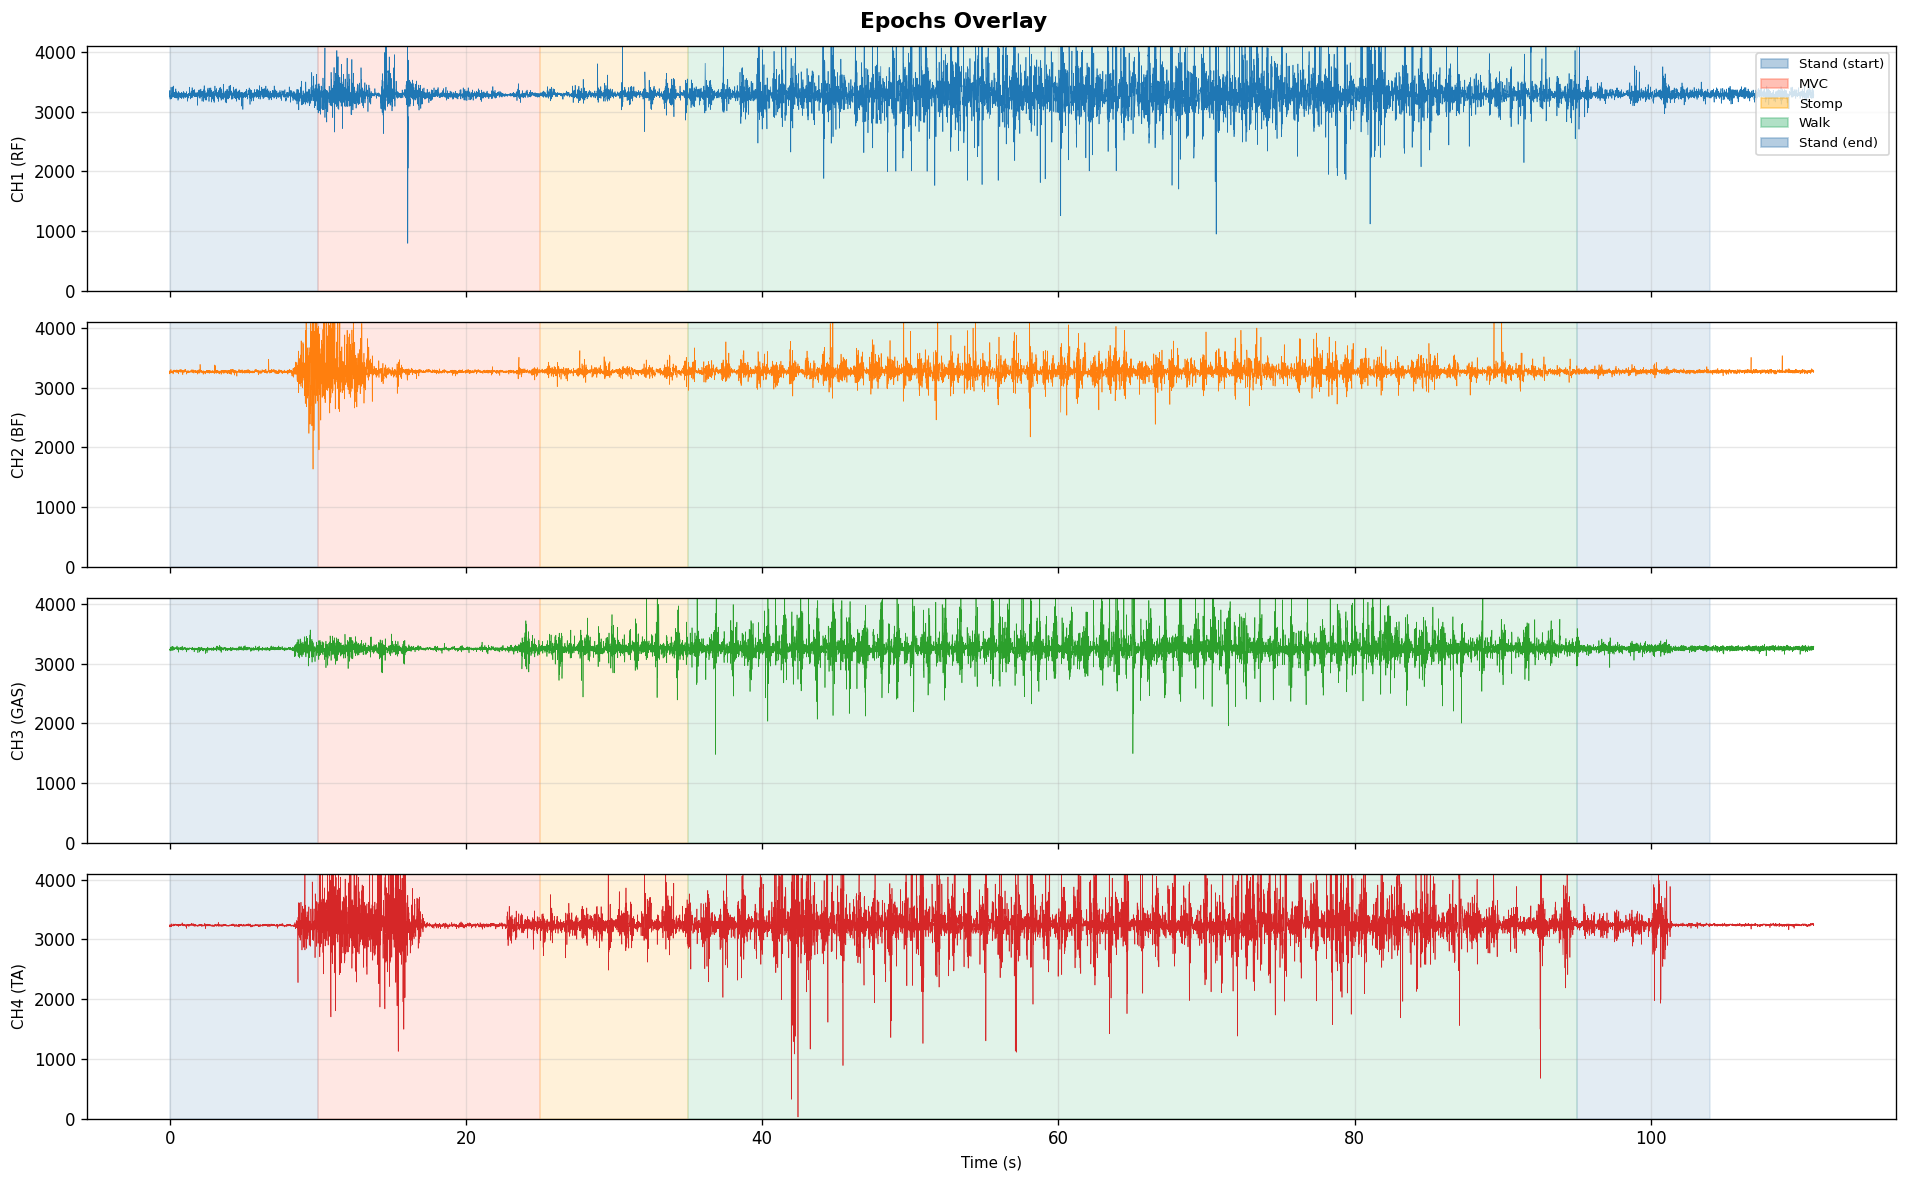

In [4]:
# ── EDIT THESE after looking at the overview ─────────────
epochs = {
    'Stand (start)': (0,   8),
    'MVC':           (8,  25),   # adjust
    'Stomp':         (25,  35),   # adjust
    'Walk':          (35,  95),   # adjust
    'Stand (end)':   (95, 104),   # adjust
}
EPOCH_COLORS = ['steelblue', 'tomato', 'orange', 'mediumseagreen', 'steelblue']

fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
fig.suptitle('Epochs Overlay', fontsize=13, fontweight='bold')

for i in range(4):
    axes[i].plot(t, adc[:,i], lw=0.4, color=CH_COLORS[i])
    axes[i].set_ylabel(CH_NAMES[i], fontsize=9)
    axes[i].set_ylim(0, 4095)
    for (name, (t0, t1)), ec in zip(epochs.items(), EPOCH_COLORS):
        axes[i].axvspan(t0, t1, alpha=0.15, color=ec)

# Legend on top plot only
patches = [mpatches.Patch(color=ec, alpha=0.4, label=name)
           for (name, _), ec in zip(epochs.items(), EPOCH_COLORS)]
axes[0].legend(handles=patches, fontsize=8, loc='upper right')
axes[-1].set_xlabel('Time (s)', fontsize=9)

plt.tight_layout()
plt.show()

## 4. Signal Processing — Bandpass + Rectify + Envelope

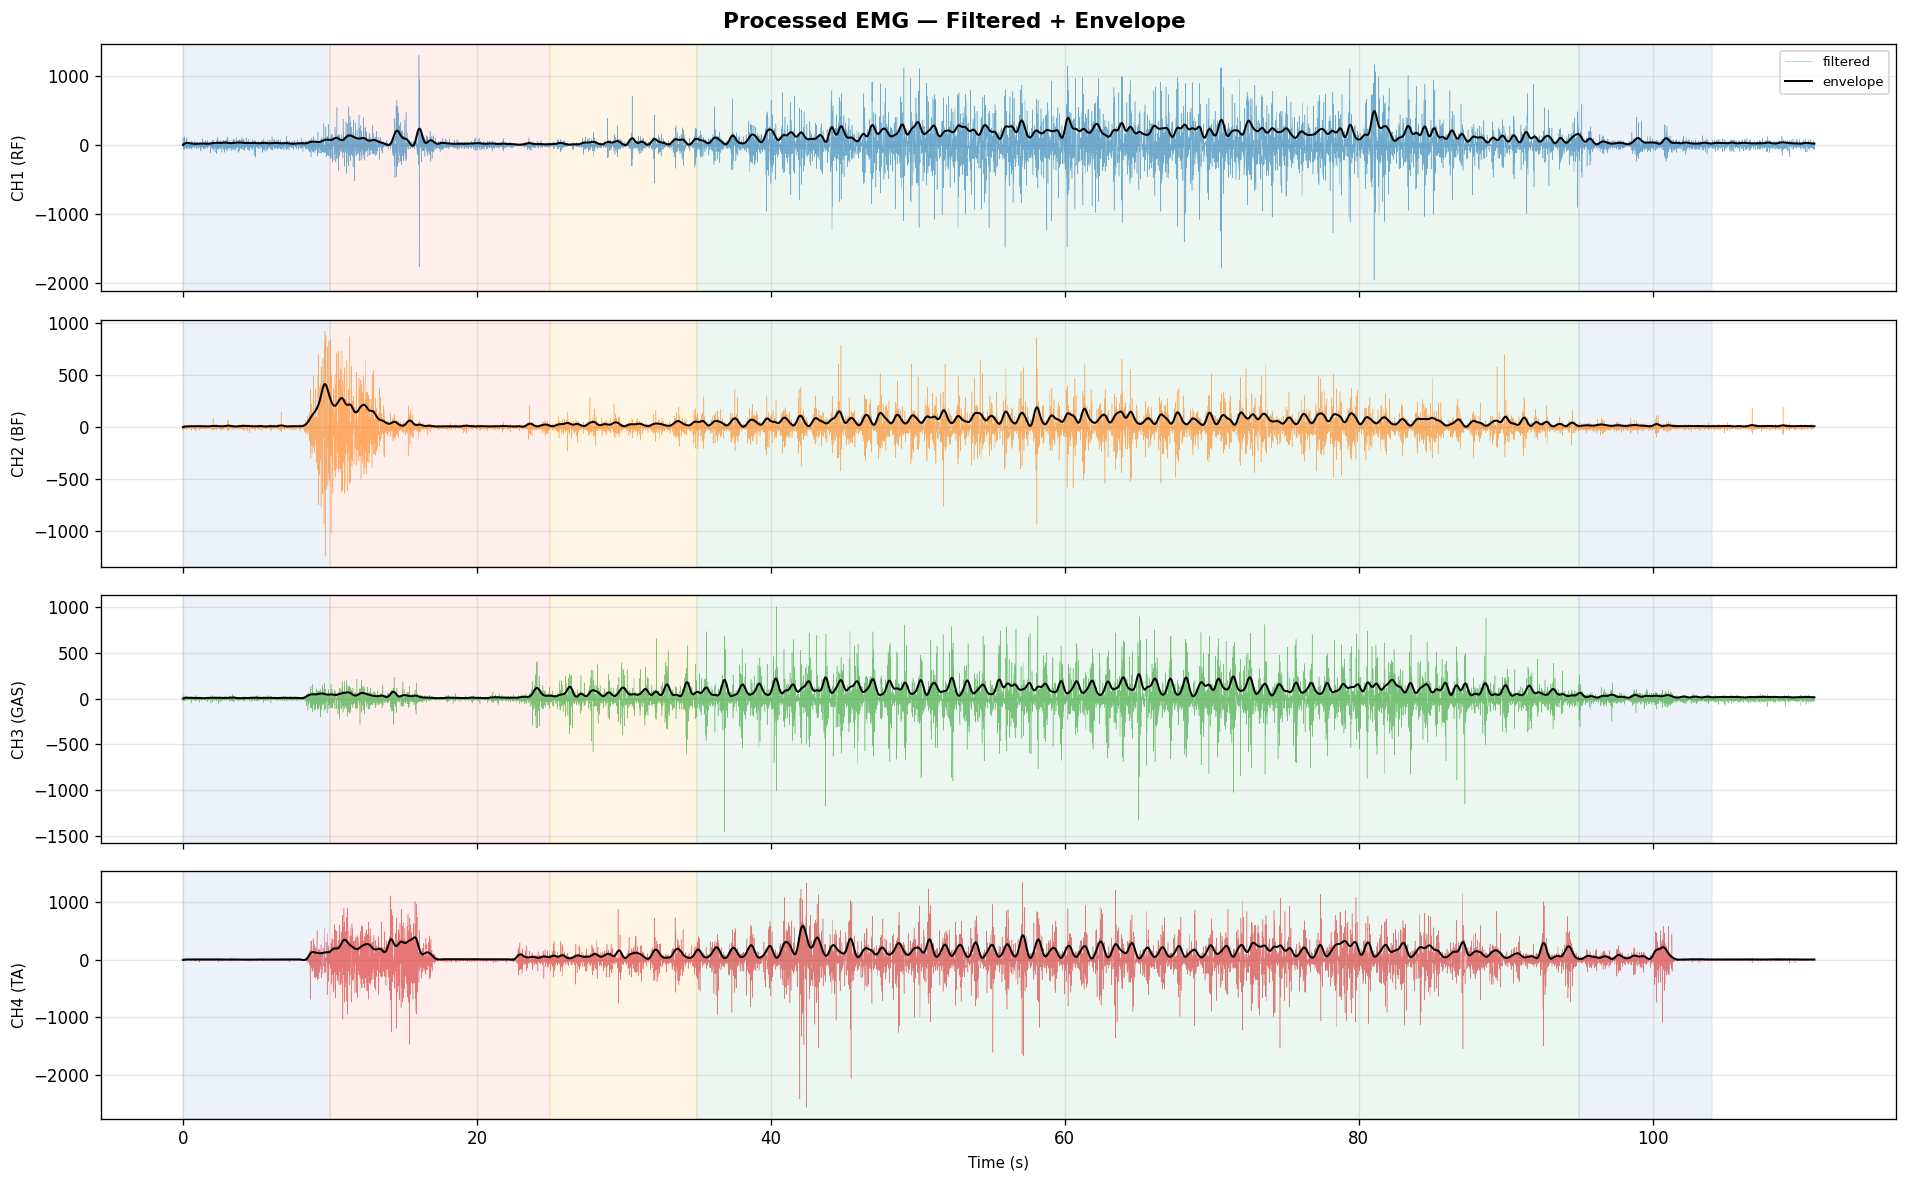

In [5]:
def process_emg(raw_ch, fs=500, bp_low=20, bp_high=200, env_cutoff=6):
    """Bandpass → demean → rectify → lowpass envelope"""
    # Remove DC offset (center around zero)
    centered = raw_ch - raw_ch.mean()
    # Bandpass 20-200 Hz (standard surface EMG)
    sos_bp = signal.butter(4, [bp_low, bp_high], btype='band', fs=fs, output='sos')
    filtered = signal.sosfiltfilt(sos_bp, centered)
    # Full-wave rectify
    rectified = np.abs(filtered)
    # Lowpass envelope
    sos_lp = signal.butter(4, env_cutoff, btype='low', fs=fs, output='sos')
    envelope = signal.sosfiltfilt(sos_lp, rectified)
    return filtered, rectified, envelope

filtered  = np.zeros_like(adc)
envelopes = np.zeros_like(adc)

for i in range(4):
    filt, rect, env = process_emg(adc[:,i])
    filtered[:,i]  = filt
    envelopes[:,i] = env

fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
fig.suptitle('Processed EMG — Filtered + Envelope', fontsize=13, fontweight='bold')

for i in range(4):
    axes[i].plot(t, filtered[:,i], lw=0.3, color=CH_COLORS[i], alpha=0.6, label='filtered')
    axes[i].plot(t, envelopes[:,i], lw=1.2, color='black', label='envelope')
    axes[i].set_ylabel(CH_NAMES[i], fontsize=9)
    for (name, (t0, t1)), ec in zip(epochs.items(), EPOCH_COLORS):
        axes[i].axvspan(t0, t1, alpha=0.1, color=ec)

axes[0].legend(fontsize=8, loc='upper right')
axes[-1].set_xlabel('Time (s)', fontsize=9)
plt.tight_layout()
plt.show()

## 5. MVC Normalization
Normalizes each channel 0–100% relative to its MVC peak envelope.

MVC peak envelope per channel:
  CH1 (RF): 238.8
  CH2 (BF): 285.1
  CH3 (GAS): 117.5
  CH4 (TA): 392.5


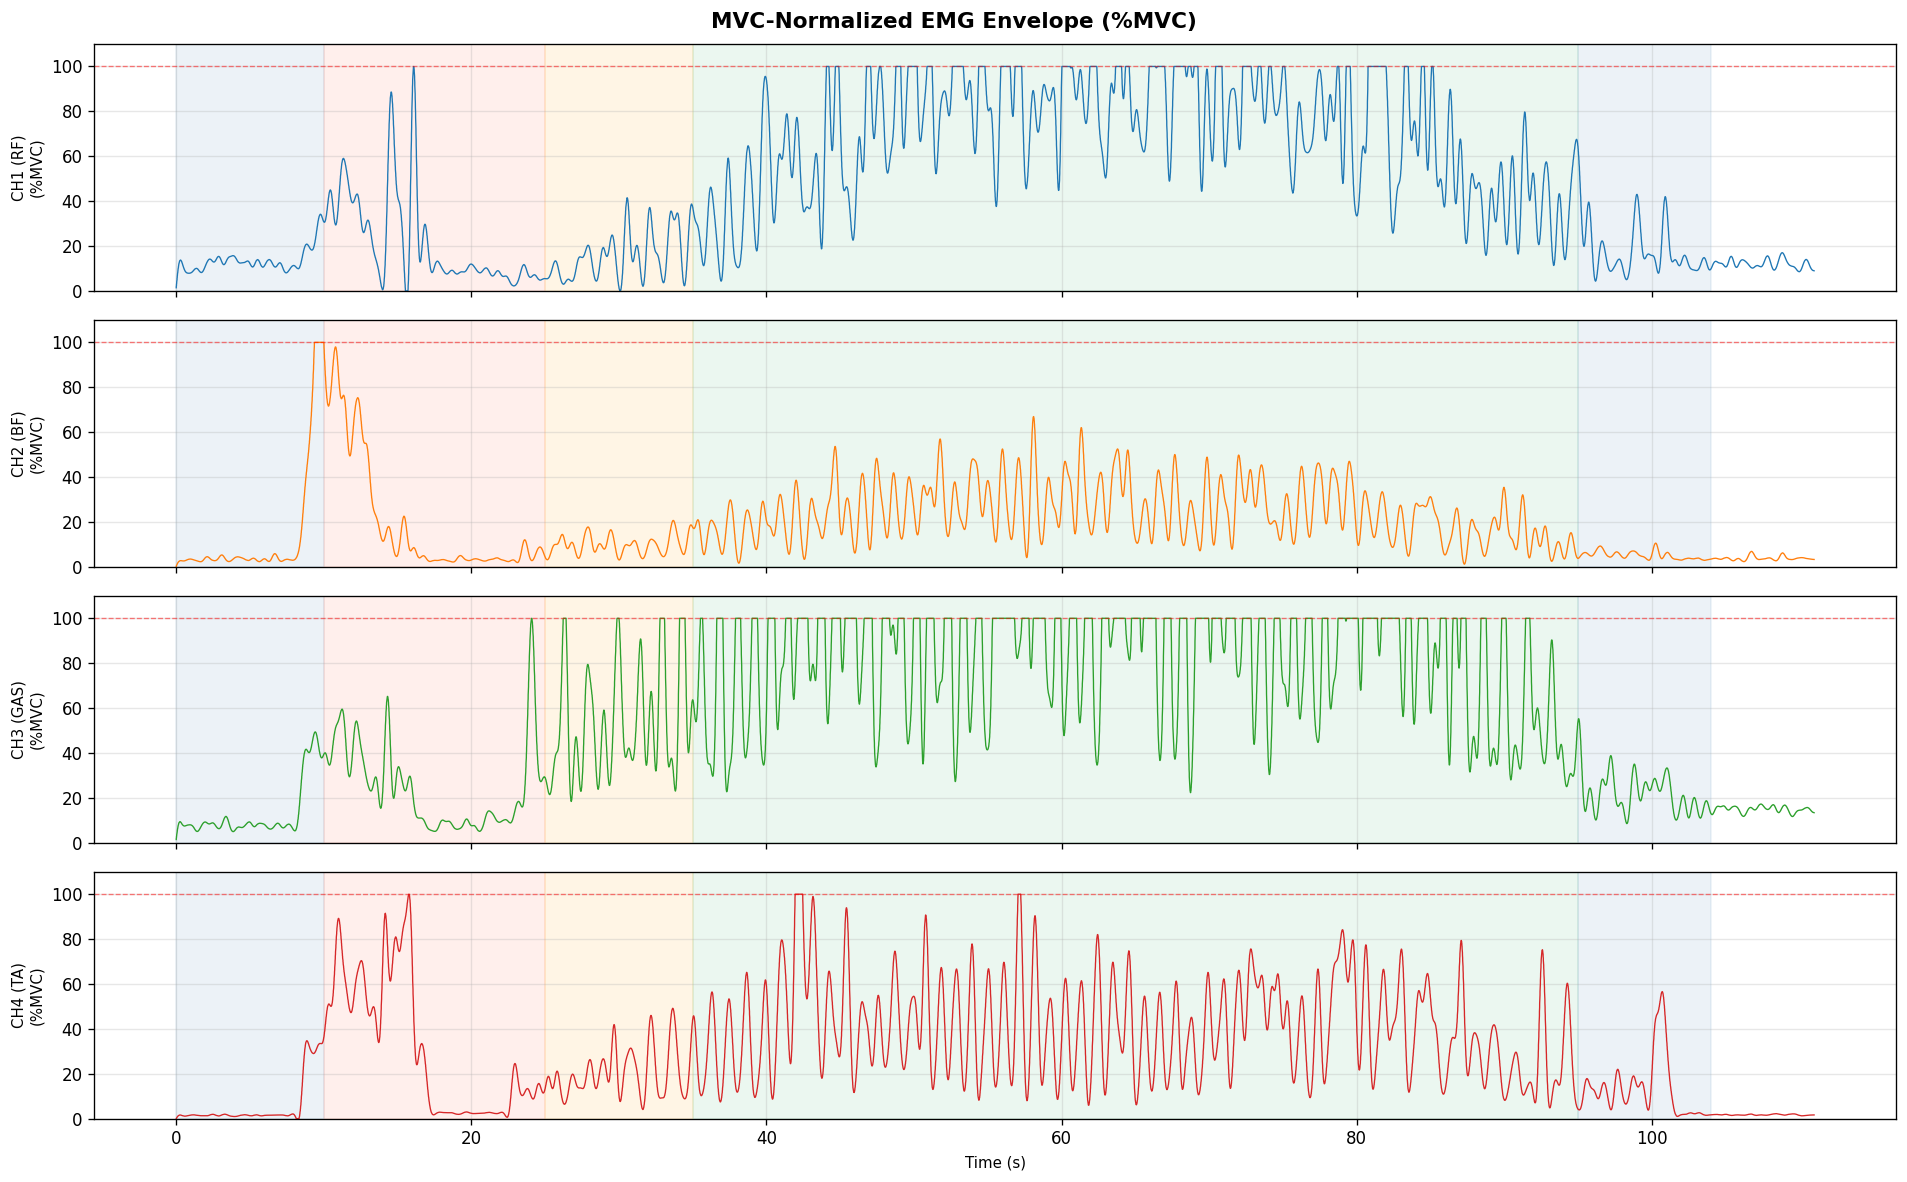

In [6]:
mvc_t0, mvc_t1 = epochs['MVC']
mvc_mask = (t >= mvc_t0) & (t <= mvc_t1)

mvc_peak = envelopes[mvc_mask].max(axis=0)
print("MVC peak envelope per channel:")
for i, name in enumerate(CH_NAMES):
    print(f"  {name}: {mvc_peak[i]:.1f}")

# Normalize (clip at 100% for any brief over-MVC moments)
normalized = np.clip(envelopes / (mvc_peak + 1e-6), 0, 1) * 100

fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
fig.suptitle('MVC-Normalized EMG Envelope (%MVC)', fontsize=13, fontweight='bold')

for i in range(4):
    axes[i].plot(t, normalized[:,i], lw=0.8, color=CH_COLORS[i])
    axes[i].set_ylabel(f'{CH_NAMES[i]}\n(%MVC)', fontsize=9)
    axes[i].set_ylim(0, 110)
    axes[i].axhline(100, color='red', lw=0.8, ls='--', alpha=0.5)
    for (name, (t0, t1)), ec in zip(epochs.items(), EPOCH_COLORS):
        axes[i].axvspan(t0, t1, alpha=0.1, color=ec)

axes[-1].set_xlabel('Time (s)', fontsize=9)
plt.tight_layout()
plt.show()

## 6. Saturation Check Per Epoch

In [7]:
print(f"{'Epoch':<20} {'CH1 TA':>10} {'CH2 BF':>10} {'CH3 GAS':>10} {'CH4 RF':>10}")
print('-' * 62)
for name, (t0, t1) in epochs.items():
    mask = (t >= t0) & (t <= t1)
    sat = [(adc[mask,i] >= 4090).mean()*100 for i in range(4)]
    print(f"{name:<20} {sat[0]:>9.1f}% {sat[1]:>9.1f}% {sat[2]:>9.1f}% {sat[3]:>9.1f}%")

Epoch                    CH1 TA     CH2 BF    CH3 GAS     CH4 RF
--------------------------------------------------------------
Stand (start)              0.0%       0.5%       0.0%       0.1%
MVC                        0.2%       0.7%       0.0%       2.1%
Stomp                      0.1%       0.0%       0.2%       0.2%
Walk                       2.4%       0.1%       0.7%       2.2%
Stand (end)                0.1%       0.0%       0.0%       0.1%


## 7. Power Spectral Density — Check for Noise / 50Hz Hum

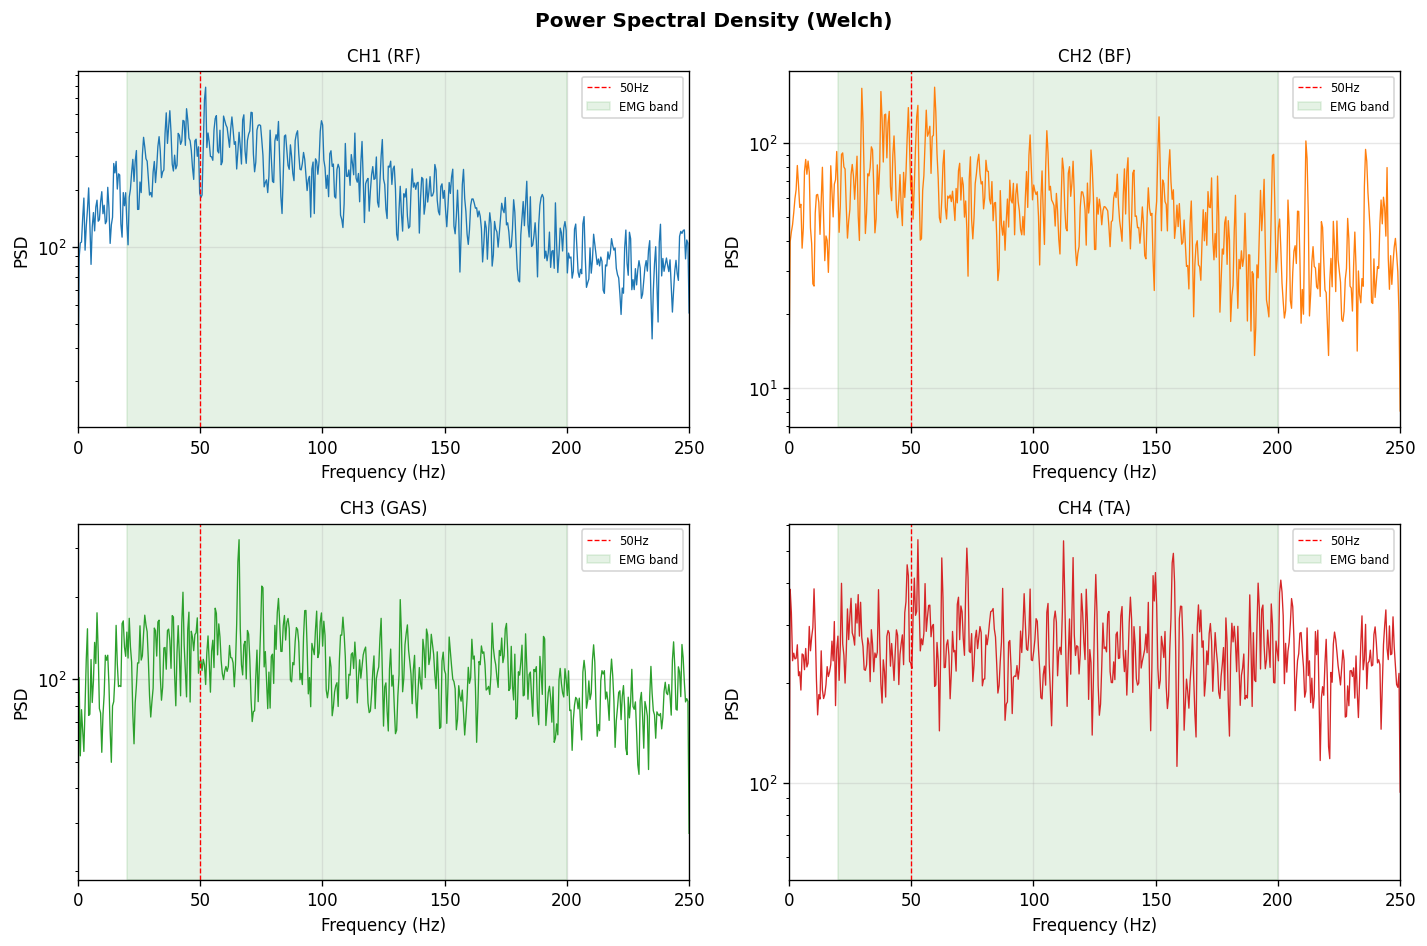

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Power Spectral Density (Welch)', fontsize=12, fontweight='bold')

for i, ax in enumerate(axes.flat):
    centered = adc[:,i] - adc[:,i].mean()
    f, psd = signal.welch(centered, fs=FS, nperseg=1024)
    ax.semilogy(f, psd, color=CH_COLORS[i], lw=0.8)
    ax.axvline(50, color='red', ls='--', lw=0.8, label='50Hz')
    ax.axvspan(20, 200, alpha=0.1, color='green', label='EMG band')
    ax.set_title(CH_NAMES[i], fontsize=10)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('PSD')
    ax.legend(fontsize=7)
    ax.set_xlim(0, 250)

plt.tight_layout()
plt.show()

## 8. Zoom Into Any Window

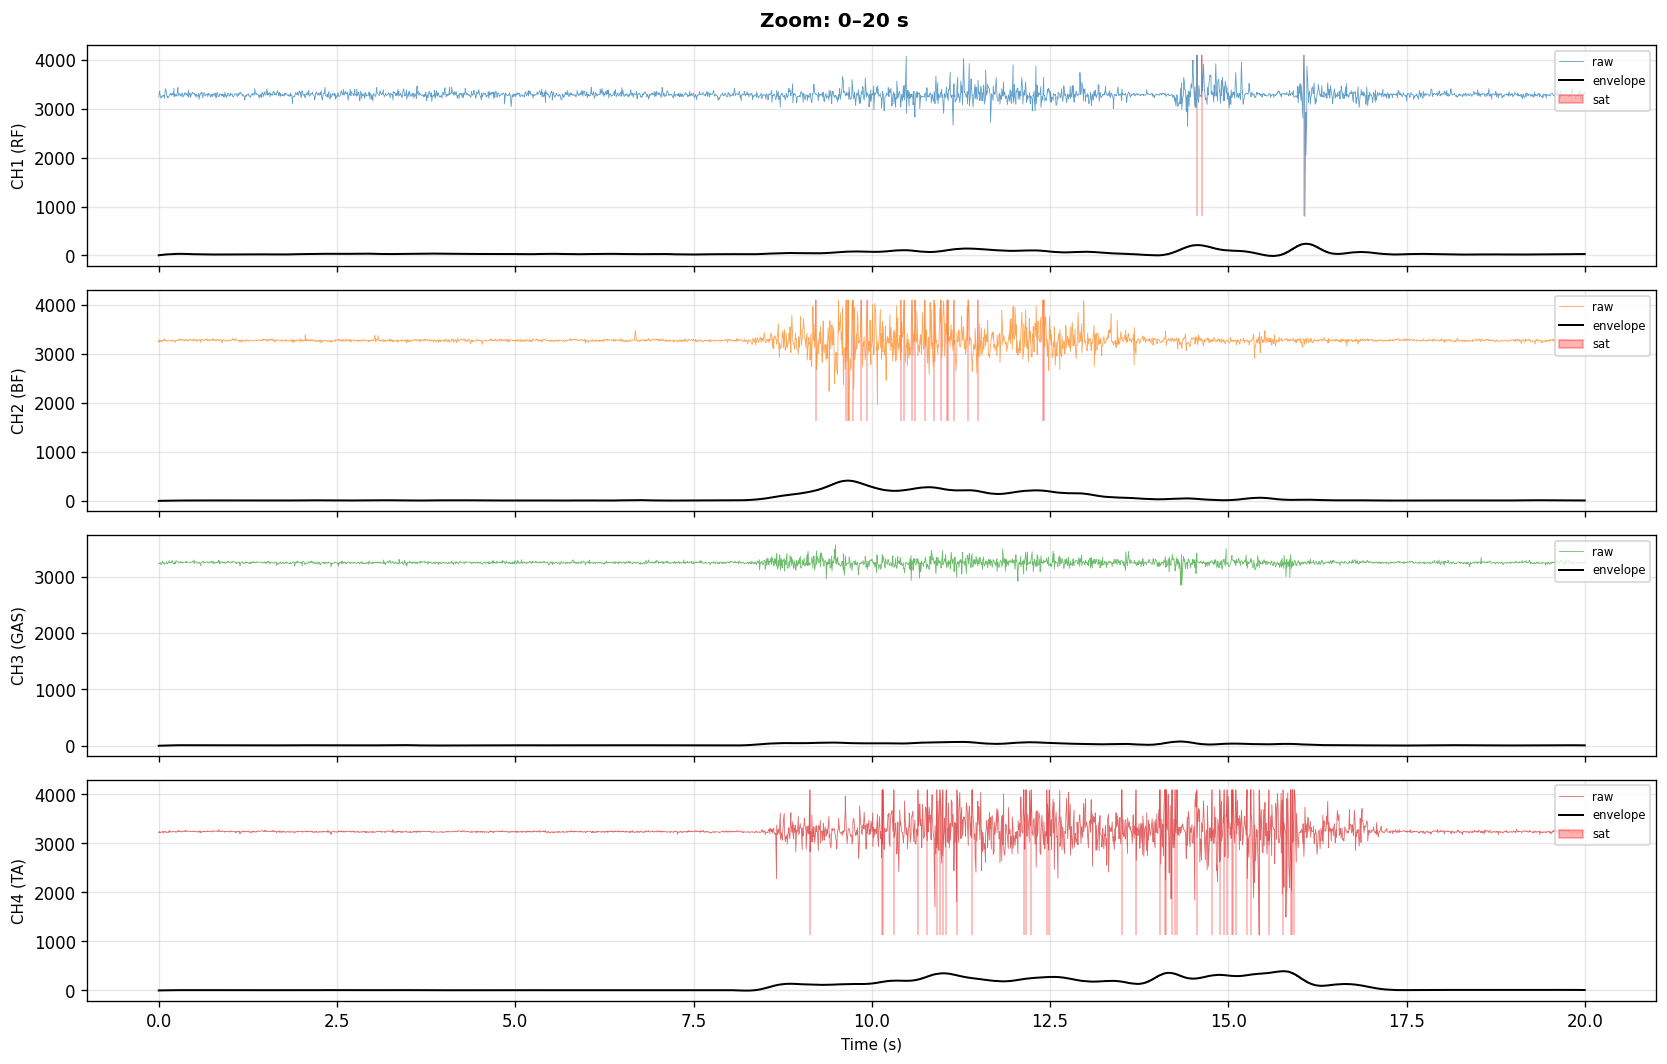

In [9]:
# ── EDIT THESE ───────────────────────────────────────────
ZOOM_T0 = 0    # seconds
ZOOM_T1 = 20   # seconds
# ─────────────────────────────────────────────────────────

mask = (t >= ZOOM_T0) & (t <= ZOOM_T1)

fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
fig.suptitle(f'Zoom: {ZOOM_T0}–{ZOOM_T1} s', fontsize=12, fontweight='bold')

for i in range(4):
    axes[i].plot(t[mask], adc[mask,i], lw=0.5, color=CH_COLORS[i], alpha=0.7, label='raw')
    axes[i].plot(t[mask], envelopes[mask,i], lw=1.2, color='black', label='envelope')
    axes[i].set_ylabel(CH_NAMES[i], fontsize=9)
    sat = adc[mask,i] >= 4090
    if sat.any():
        axes[i].fill_between(t[mask], adc[mask,i].min(), adc[mask,i].max(),
                             where=sat, alpha=0.3, color='red', label='sat')
    axes[i].legend(fontsize=7, loc='upper right')

axes[-1].set_xlabel('Time (s)', fontsize=9)
plt.tight_layout()
plt.show()

## 9. IMU Detail

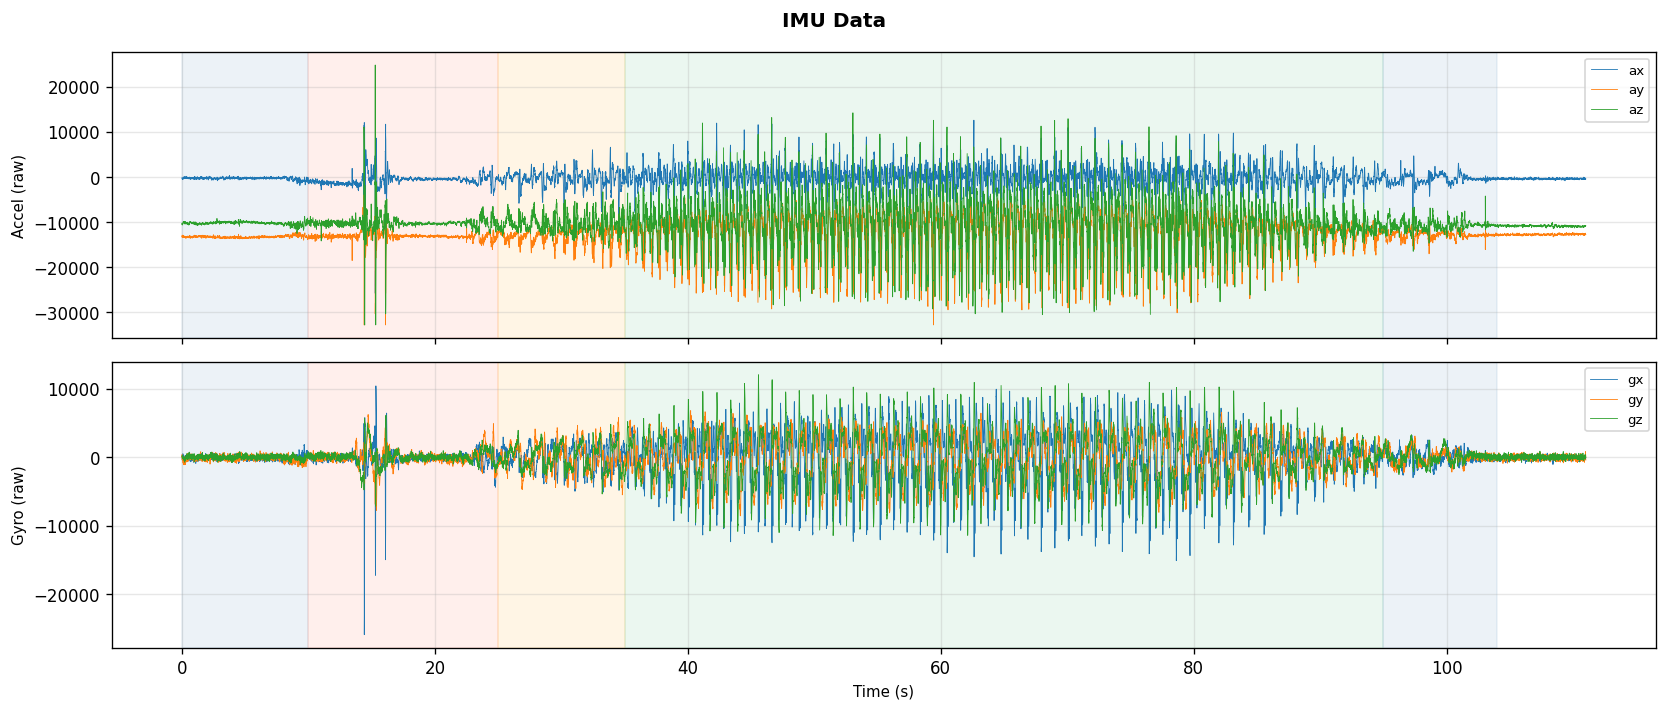

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
fig.suptitle('IMU Data', fontsize=12, fontweight='bold')

labels_accel = ['ax', 'ay', 'az']
labels_gyro  = ['gx', 'gy', 'gz']

for i in range(3):
    axes[0].plot(t, imu[:,i], lw=0.5, label=labels_accel[i])
    axes[1].plot(t, imu[:,3+i], lw=0.5, label=labels_gyro[i])

axes[0].set_ylabel('Accel (raw)', fontsize=9)
axes[1].set_ylabel('Gyro (raw)', fontsize=9)
axes[1].set_xlabel('Time (s)', fontsize=9)

for ax in axes:
    ax.legend(fontsize=8, loc='upper right')
    for (name, (t0, t1)), ec in zip(epochs.items(), EPOCH_COLORS):
        ax.axvspan(t0, t1, alpha=0.1, color=ec)

plt.tight_layout()
plt.show()